# Temperature Visualization

This notebook plots entropy vs temperature using the local sampling simulator.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

def add_local_path() -> Path:
    cwd = Path.cwd()
    candidates = [cwd / "notebooks" / "local", cwd]
    for candidate in candidates:
        if (candidate / "sampling_simulator.py").exists():
            sys.path.insert(0, str(candidate))
            return candidate
    raise FileNotFoundError("Could not locate sampling_simulator.py")

local_dir = add_local_path()
from docs.notebooks.sampling_simulator import run_experiment


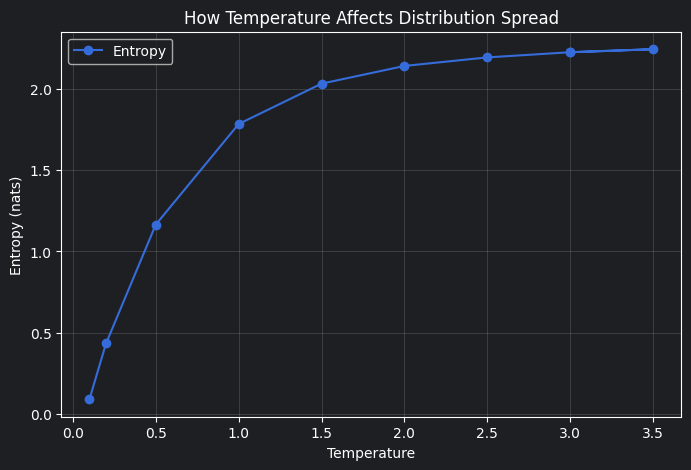

In [4]:
tokens = [
    "approve", "reject", "review", "escalate", "delay",
    "audit", "optimize", "notify", "assign", "close"
]
logits = np.array([2.2, 1.8, 1.4, 0.9, 0.2, 0.1, -0.3, -0.6, -0.8, -1.0], dtype=float)
temps = [0.1, 0.2, 0.5, 1.0, 1.5, 2.0,2.5,3.0,3.5,3.0]

entropies = []
for t in temps:
    out = run_experiment(tokens, logits, temperature=t, n_samples=10000)
    entropies.append(out["entropy"])

plt.figure(figsize=(8, 5))
plt.plot(temps, entropies, marker="o", label="Entropy")
plt.xlabel("Temperature")
plt.ylabel("Entropy (nats)")
plt.title("How Temperature Affects Distribution Spread")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [5]:
# Optional: save a copy for docs/sharing
out_path = local_dir / "temperature_entropy.png"
plt.figure(figsize=(8, 5))
plt.plot(temps, entropies, marker="o", label="Entropy")
plt.xlabel("Temperature")
plt.ylabel("Entropy (nats)")
plt.title("How Temperature Affects Distribution Spread")
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.close()
print(f"Saved plot to {out_path}")


Saved plot to /Users/nchaur590@cable.comcast.com/Programming/ai-parameter-playbook/experiments/temperature_entropy.png
